The Boston Housing Dataset

The Boston Housing Dataset is a derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA. The following describes the dataset columns:

```
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's
```

## Manual Pearson Coeff

In [20]:
import pandas as pd
import numpy as np


# Load the Boston housing dataset
boston = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


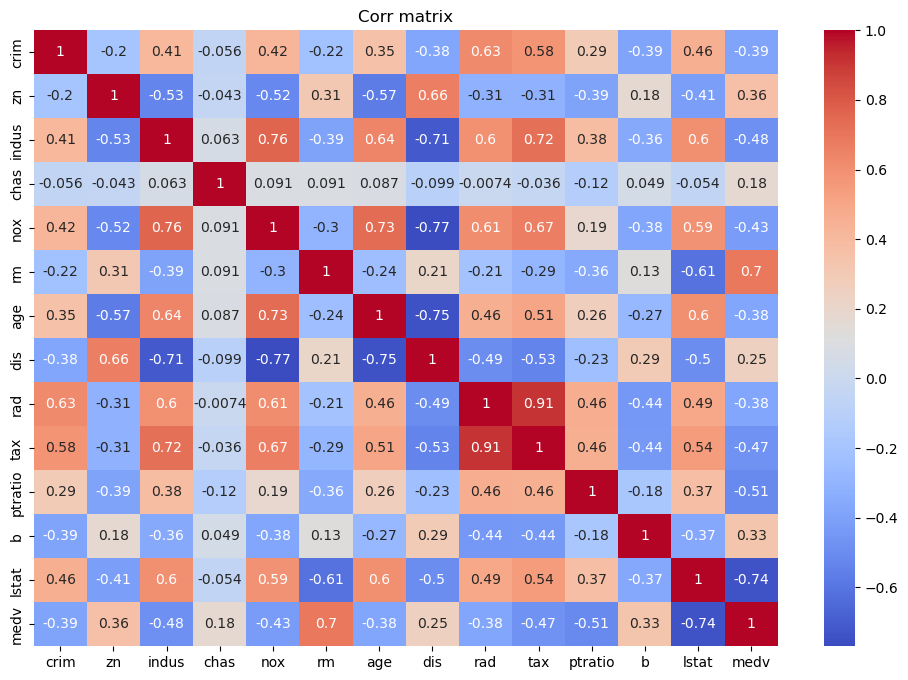

In [21]:
## Approach 1 correlation 
# calc corr matrix
correlation_matrix = boston.corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Corr matrix')
plt.show()

### Based on the corr matrix, identify highly correlated feats. A commonly used threshold is corr coeff greater than or equal 0.8 or less that or equal -0.8

In [22]:
# eg, removing highly correlated feat pairs
threshold = 0.8

high_corr_features = np.where(np.abs(correlation_matrix.values[:-1,:-1]) >= threshold)

# a set to store the feats to remove
features_to_remove = set()

#iterate via the pairs and remove one of the correlated feats
for i,j in zip(*high_corr_features):
    if i!=j and i not in features_to_remove and j not in features_to_remove:
        # remove that feature which has low correlation with target column
        features_to_remove.add(j if np.abs(correlation_matrix.medv.iloc[i]) > np.abs(correlation_matrix.medv.iloc[j]) else i)

df_filtered_corr = boston.drop(boston.columns[list(features_to_remove)], axis=1)
print(features_to_remove)

{np.int64(8)}


In [23]:
df_filtered_corr

,crim,zn,indus,chas,nox,rm,age,dis,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,273,21.0,393.45,6.48,22.0


### VIF Approach
To remove multicollinear cols using Variance Inflation Factor

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# extract the independent variables (feats) and target variable
X  = boston.drop('medv', axis=1)

# calc the vif for each feat
vif = pd.DataFrame()
vif["Feature"]  = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,crim,2.100373
1,zn,2.844013
2,indus,14.485758
3,chas,1.152952
4,nox,73.894947
5,rm,77.948283
6,age,21.386850
7,dis,14.699652
8,rad,15.167725
9,tax,61.227274


* 2. **Analyze the VIF values.**

    Inspect the VIF values for each feature. Higher VIF values indicate a stronger multicollinearity. A commonly used threshold to detect multicollinearity is a VIF value greater than 5 or 10.

In [25]:
vif_threshold = 5

# identify high vif vals
high_vif_features = vif[vif['VIF'] > vif_threshold]['Feature'].values

# remove feats with high vif vals
df_filtered_vif = boston.drop(high_vif_features, axis = 1)

df_filtered_vif

,crim,zn,chas,medv
0,0.00632,18.0,0,24.0
1,0.02731,0.0,0,21.6
2,0.02729,0.0,0,34.7
3,0.03237,0.0,0,33.4
4,0.06905,0.0,0,36.2
...,...,...,...,...
501,0.06263,0.0,0,22.4
502,0.04527,0.0,0,20.6
503,0.06076,0.0,0,23.9
504,0.10959,0.0,0,22.0


## SKIPPING CONDITION NUMBER APPROACH.

## VarianceThreshold,  SelectKBest, chi2, f_classif

In [26]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif

data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQtBXo5cBnDsM2fmfHPm6u72KGUS5FjPHNGMxOfYjA9-CAhmnRpwkIw_rOR3sANJIToiUU__6fbBvig/pub?gid=572763137&single=true&output=csv"


DATA = pd.read_csv(data_path)

duplicated_cols  = DATA.columns[DATA.T.duplicated()]

duplicated_cols

Index(['149', '179', '186', '189', '191', '192', '193', '194', '226', '229',
       ...
       '529', '530', '531', '532', '533', '534', '535', '536', '537', '538'],
      dtype='str', length=104)

In [27]:
data = DATA.drop(columns=duplicated_cols)

data.drop('Time', inplace=True, axis=1)

print('number of cols  =', DATA.shape[1])
print("Number of Columns after removing duplicate columns- ", data.shape[1])

number of cols  = 592
Number of Columns after removing duplicate columns-  487


In [28]:
# VARIANCE THRESHOLD METHOD
selector = VarianceThreshold(threshold= 0.01)
sel = selector.fit(data)

columns = data.columns[sel.get_support()]

data_vt = sel.transform(data)

data_vt = pd.DataFrame(data_vt, columns = columns)

# Numbers Of Columns after Variance Threshold Method

print("Number of Columns after Variance Threshold Method- ", data_vt.shape[1])

Number of Columns after Variance Threshold Method-  315


In [29]:
# Correlation

corr_matrix = data_vt.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool_))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
data_corr = data_vt.drop(to_drop, axis=1)

print("Number of Columns after Correlation- ", data_corr.shape[1])

Number of Columns after Correlation-  162


In [30]:
data_corr.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 162 entries, 0 to Pass/Fail
dtypes: float64(162)
memory usage: 1.9 MB


We can still perform ANOVA analysis by considering each column separately.

ANOVA can be applied to each column individually, comparing the target variable which is Pass/Fail column in our case against the non-missing values in that specific column.

We will drop NaN values of each column before performing the ANOVA

In [31]:
from scipy.stats import f_oneway

# Significance Value
alpha = 0.05

# Columns haveing p_value less than alpha
column_pvalues = []

# Iterate over each column
for column in data_corr.iloc[:, :-1].columns:
    # Extract the non-missing values in the column
    column_data = data_corr[column].dropna()

    # Perform ANOVA with the target variable
    anova_result = f_oneway(column_data, data_corr['Pass/Fail'])

    # Print the ANOVA result or perform further analysis
    print(f"Column: {column} - ANOVA p-value: {anova_result.pvalue}")

    if anova_result.pvalue <= alpha:
        column_pvalues.append((column, anova_result.pvalue))

# Selecting best 100 Features - lower p-value better feature
# Sort the column p-values in ascending order
column_pvalues.sort(key=lambda x: x[1])

# Select the top 100 columns with the lowest p-values
selected_columns = [column for column, _ in column_pvalues[:100]]

data_anova = data_corr[selected_columns+['Pass/Fail']]

print("Number of Columns after Correlation- ", data_anova.shape[1])


Column: 0 - ANOVA p-value: 0.0
Column: 1 - ANOVA p-value: 0.0
Column: 2 - ANOVA p-value: 0.0
Column: 3 - ANOVA p-value: 0.0
Column: 4 - ANOVA p-value: 0.0003805229753157006
Column: 6 - ANOVA p-value: 0.0
Column: 12 - ANOVA p-value: 0.0
Column: 14 - ANOVA p-value: 0.0
Column: 15 - ANOVA p-value: 0.0
Column: 16 - ANOVA p-value: 0.0
Column: 18 - ANOVA p-value: 0.0
Column: 19 - ANOVA p-value: 0.0
Column: 21 - ANOVA p-value: 0.0
Column: 22 - ANOVA p-value: 0.0
Column: 23 - ANOVA p-value: 0.0
Column: 24 - ANOVA p-value: 5.021119420795212e-05
Column: 25 - ANOVA p-value: 0.0
Column: 28 - ANOVA p-value: 0.0
Column: 29 - ANOVA p-value: 0.0
Column: 31 - ANOVA p-value: 0.0
Column: 32 - ANOVA p-value: 0.0
Column: 33 - ANOVA p-value: 0.0
Column: 34 - ANOVA p-value: 0.0
Column: 35 - ANOVA p-value: 0.0
Column: 37 - ANOVA p-value: 0.0
Column: 38 - ANOVA p-value: 0.0
Column: 39 - ANOVA p-value: 0.0
Column: 40 - ANOVA p-value: 0.0
Column: 41 - ANOVA p-value: 0.0
Column: 43 - ANOVA p-value: 0.0
Column: 44

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Shape of Data after Feature Selection

print("Shape - ", data_anova.shape)

# Filling NaN Values with random
for column in data_anova.columns:
    # print("Column- ", column)
    # Get the minimum and maximum values of the column
    min_value = data_anova[column].min()
    max_value = data_anova[column].max()

    # Generate random numbers within the range
    random_values = np.random.uniform(min_value, max_value, size=data_anova[column].isnull().sum())

    # Create a Series with the random values
    random_series = pd.Series(random_values, index=data_anova[column][data_anova[column].isnull()].index)

    # Fill NaN values with the random series
    data_anova[column].fillna(random_series, inplace=True)

    # Print
    # print(data[column].isnull().sum())


# Separate features and target
X = data_anova.drop('Pass/Fail', axis=1)
y = data_anova['Pass/Fail']



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)


print(X_train.isnull().sum(), X_test.isnull().sum())

Shape -  (1567, 101)
(1253, 100)
(314, 100)
0       5
1       3
2      14
3      14
6      14
       ..
438     1
439     1
442     1
443     1
444     1
Length: 100, dtype: int64 0      1
1      4
2      0
3      0
6      0
      ..
438    1
439    1
442    0
443    0
444    0
Length: 100, dtype: int64


/tmp/ipykernel_762767/2044988853.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_anova[column].fillna(random_series, inplace=True)


In [34]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=10000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

# anova doesn't works with NAN values. 

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## K-best features

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

%matplotlib inline

In [37]:
wine_data = load_wine()

wine_df = pd.DataFrame(
    data=wine_data.data,
    columns=wine_data.feature_names
)

wine_df['target'] = wine_data.target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


/home/blix/anaconda3/envs/machine-learning/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/blix/anaconda3/envs/machine-learning/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/blix/anaconda3/envs/machine-learning/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 44.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/blix/anaconda3/envs/machine-learning/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 36.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, U

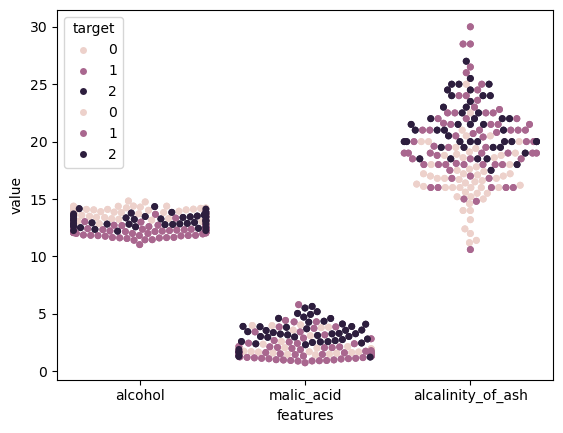

In [39]:
from seaborn import swarmplot

data_to_plot = pd.melt(wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
                       id_vars='target',
                       var_name='features',
                       value_name='value')

swarmplot(data=data_to_plot, x='features', y='value', hue='target');from seaborn import swarmplot

data_to_plot = pd.melt(wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
                       id_vars='target',
                       var_name='features',
                       value_name='value')

swarmplot(data=data_to_plot, x='features', y='value', hue='target');

In [40]:
from sklearn.model_selection import train_test_split

X = wine_df.drop(['target'], axis=1)
y = wine_df['target']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.3,
                                                   shuffle=True,
                                                   stratify=y,
                                                   random_state=42)